In [53]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Operator
from tqdm.notebook import tqdm
from weylchamber import WeylChamber, c1c2c3
from hetero_isas.zz_parallel_drive.bgate import BGate
from hetero_isas.zz_parallel_drive.hamiltonian import ZZ_ParallelDrive
from qiskit.circuit.library import iSwapGate, CXGate, CZGate
import matplotlib.pyplot as plt
from itertools import product, permutations

In [2]:
N = 10_000
REDUCE_COORD = False

In [3]:
# test pulse-optimized circuits,
# what is the middle interleaving 1Q layers are not fully expressive?
# NOTE, set \theta to np.pi/2 to get a "pulse-optimized" circuit
# instead of VZ-SX-VZ-SX-VZ can be VZ-SX-VZ

pd_coord_list = []

basis_gate = lambda denom: ZZ_ParallelDrive(
    g_zz=3 * np.pi / denom,  # [4, 8, 16],
    g_ix=np.pi**2 / 5,
    g_xi=np.pi**2 / 5,
    # g_zi=np.pi / 8,
    # g_iz=np.pi / 8,
).to_unitary()


def _generate(b1, b2):
    qc = QuantumCircuit(2)
    qc.append(basis_gate(b1), [0, 1])
    qc.u(np.pi / 2, Parameter("x2"), Parameter("x3"), 0)
    qc.u(np.pi / 2, Parameter("x5"), Parameter("x6"), 1)
    qc.append(basis_gate(b2), [0, 1])

    temp_coord_list = []
    for _ in tqdm(range(N)):
        temp_qc = qc  # XXX
        for param in qc.parameters:
            temp_qc = temp_qc.assign_parameters(
                {param: np.random.uniform(0, 2 * np.pi)}
            )
        temp_coord_list.append(list(c1c2c3(Operator(temp_qc)._data)))
    return temp_coord_list


pd_coord_list.append(_generate(4, 4))
pd_coord_list.append(_generate(4, 8))
pd_coord_list.append(_generate(8, 8))
pd_coord_list.append(_generate(4, 16))
pd_coord_list.append(_generate(8, 16))
pd_coord_list.append(_generate(16, 16))

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

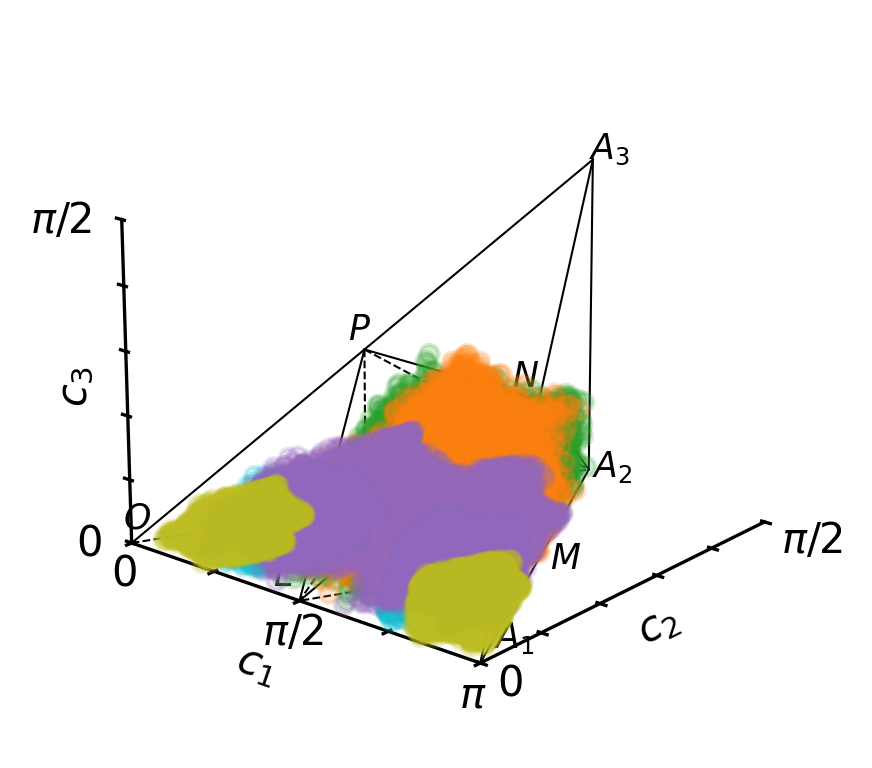

In [4]:
w = WeylChamber()
colors = ["tab:orange", "tab:green", "tab:purple", "tab:red", "tab:cyan", "tab:olive"]
for idx, inner_coord_list in enumerate(pd_coord_list):
    for c in inner_coord_list:
        c[0] = 1 - c[0] if (REDUCE_COORD and c[0] > 0.5) else c[0]
        w.add_point(*c, color=colors[idx], scatter_index=idx, alpha=0.2)
w.plot()

In [9]:
# test pulse-optimized circuits,
# what is the middle interleaving 1Q layers are not fully expressive?
# NOTE, set \theta to np.pi/2 to get a "pulse-optimized" circuit
# instead of VZ-SX-VZ-SX-VZ can be VZ-SX-VZ

b_coord_list = []


def _generate(b1, b2):
    qc = QuantumCircuit(2)
    qc.append(BGate(b1), [0, 1])
    qc.u(np.pi / 2, Parameter("x2"), Parameter("x3"), 0)
    qc.u(np.pi / 2, Parameter("x5"), Parameter("x6"), 1)
    qc.append(BGate(b2), [0, 1])

    temp_coord_list = []
    for _ in tqdm(range(N)):
        temp_qc = qc  # XXX
        for param in qc.parameters:
            temp_qc = temp_qc.assign_parameters(
                {param: np.random.uniform(0, 2 * np.pi)}
            )
        temp_coord_list.append(list(c1c2c3(Operator(temp_qc)._data)))
    return temp_coord_list


b_coord_list.append(_generate(np.pi / 2, np.pi / 2))
b_coord_list.append(_generate(np.pi / 2, np.pi / 4))
b_coord_list.append(_generate(np.pi / 4, np.pi / 4))
b_coord_list.append(_generate(np.pi / 2, np.pi / 8))
b_coord_list.append(_generate(np.pi / 4, np.pi / 8))
b_coord_list.append(_generate(np.pi / 8, np.pi / 8))

  0%|          | 0/10000 [00:00<?, ?it/s]

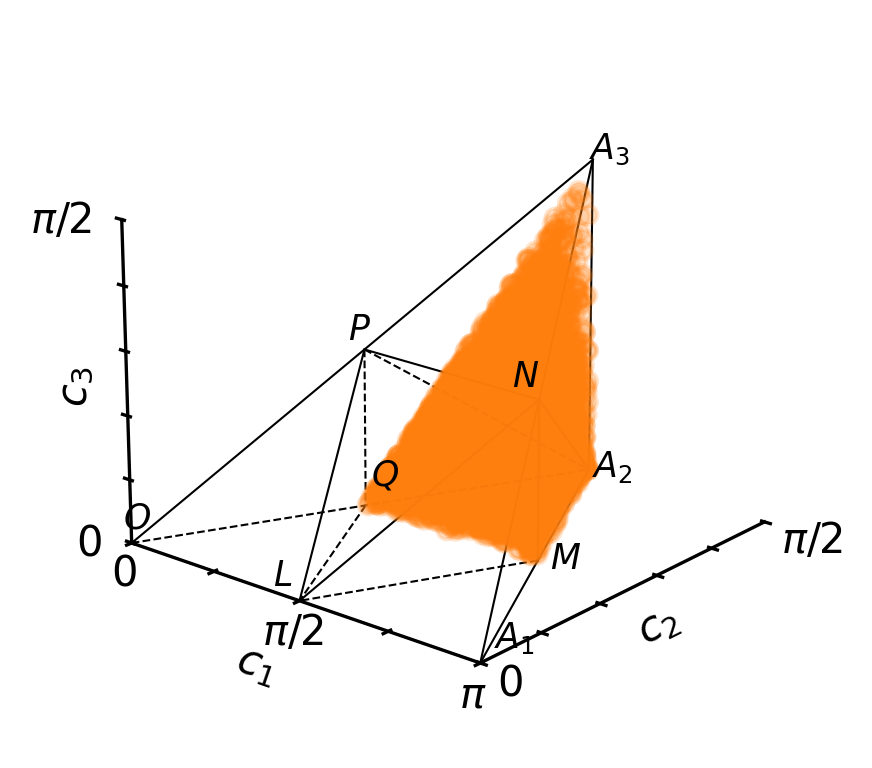

In [10]:
w = WeylChamber()
colors = ["tab:orange", "tab:green", "tab:purple", "tab:red", "tab:cyan", "tab:olive"]
for idx, inner_coord_list in enumerate(b_coord_list):
    for c in inner_coord_list:
        c[0] = 1 - c[0] if (REDUCE_COORD and c[0] > 0.5) else c[0]
        w.add_point(*c, color=colors[idx], scatter_index=idx, alpha=0.2)
w.plot()

In [32]:
cx_coord_list = []


def _generate(b1, b2):
    qc = QuantumCircuit(2)
    qc.append(CXGate().power(b1), [0, 1])
    qc.u(np.pi / 2, Parameter("x2"), Parameter("x3"), 0)
    qc.u(np.pi / 2, Parameter("x5"), Parameter("x6"), 1)
    qc.append(CXGate().power(b2), [0, 1])

    temp_coord_list = []
    for _ in tqdm(range(N)):
        temp_qc = qc  # XXX
        for param in qc.parameters:
            temp_qc = temp_qc.assign_parameters(
                {param: np.random.uniform(0, 2 * np.pi)}
            )
        temp_coord_list.append(list(c1c2c3(Operator(temp_qc)._data)))
    return temp_coord_list


cx_coord_list.append(_generate(1, 1))
cx_coord_list.append(_generate(1, 1 / 2))
cx_coord_list.append(_generate(1 / 2, 1 / 2))
cx_coord_list.append(_generate(1, 1 / 4))
cx_coord_list.append(_generate(1 / 2, 1 / 4))
cx_coord_list.append(_generate(1 / 4, 1 / 4))

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

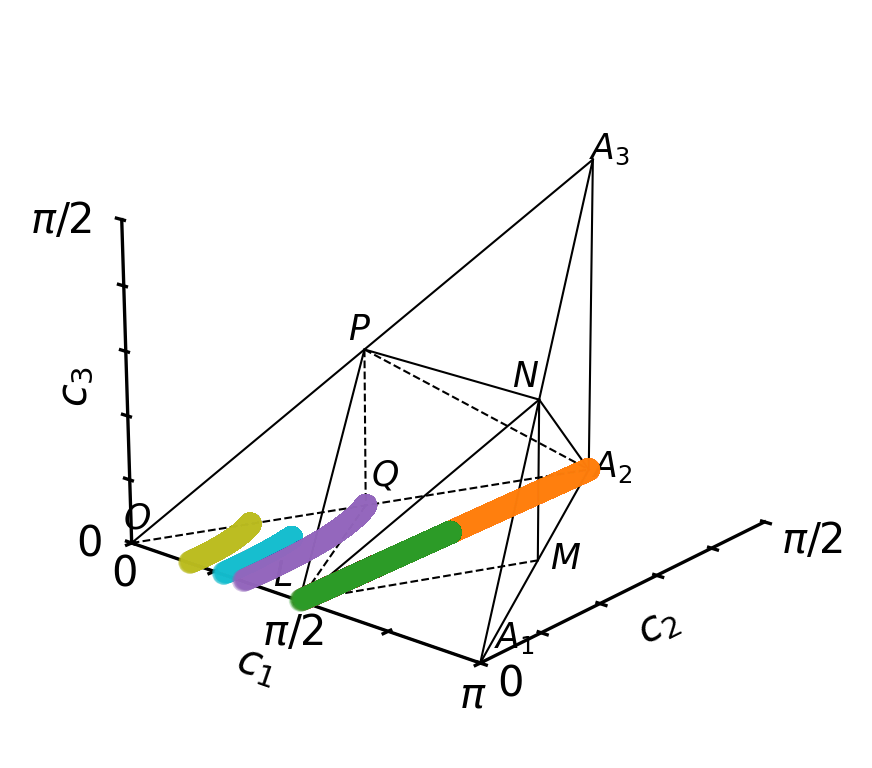

In [33]:
w = WeylChamber()
colors = ["tab:orange", "tab:green", "tab:purple", "tab:red", "tab:cyan", "tab:olive"]
for idx, inner_coord_list in enumerate(cx_coord_list):
    for c in inner_coord_list:
        c[0] = 1 - c[0] if (REDUCE_COORD and c[0] > 0.5) else c[0]
        w.add_point(*c, color=colors[idx], scatter_index=idx, alpha=0.2)
w.plot()

In [34]:
iswap_coord_list = []


def _generate(b1, b2):
    qc = QuantumCircuit(2)
    # qc.append(BGate(b1), [0, 1])
    qc.append(iSwapGate().power(b1), [0, 1])
    qc.u(np.pi / 2, Parameter("x2"), Parameter("x3"), 0)
    qc.u(np.pi / 2, Parameter("x5"), Parameter("x6"), 1)
    qc.append(iSwapGate().power(b2), [0, 1])

    temp_coord_list = []
    for _ in tqdm(range(N)):
        temp_qc = qc  # XXX
        for param in qc.parameters:
            temp_qc = temp_qc.assign_parameters(
                {param: np.random.uniform(0, 2 * np.pi)}
            )
        temp_coord_list.append(list(c1c2c3(Operator(temp_qc)._data)))
    return temp_coord_list


iswap_coord_list.append(_generate(1, 1))
iswap_coord_list.append(_generate(1, 1 / 2))
iswap_coord_list.append(_generate(1 / 2, 1 / 2))
iswap_coord_list.append(_generate(1, 1 / 4))
iswap_coord_list.append(_generate(1 / 2, 1 / 4))
iswap_coord_list.append(_generate(1 / 4, 1 / 4))

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

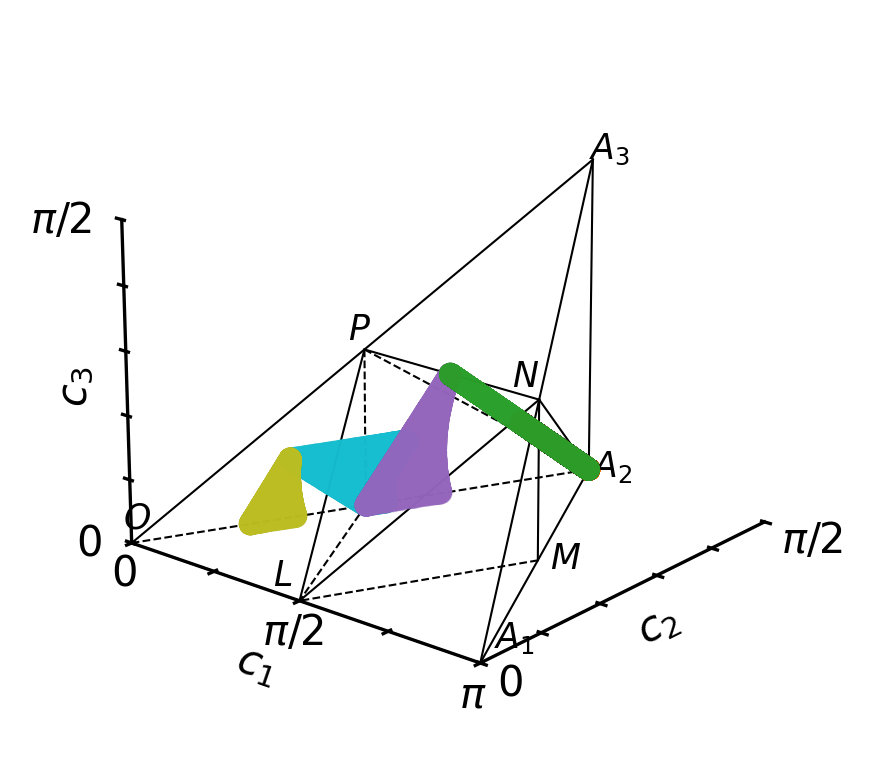

In [35]:
w = WeylChamber()
colors = ["tab:orange", "tab:green", "tab:purple", "tab:red", "tab:cyan", "tab:olive"]
for idx, inner_coord_list in enumerate(iswap_coord_list):
    for c in inner_coord_list:
        c[0] = 1 - c[0] if (REDUCE_COORD and c[0] > 0.5) else c[0]
        w.add_point(*c, color=colors[idx], scatter_index=idx, alpha=0.2)
w.plot()